In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("default")

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

load data

In [4]:
df = pd.read_csv("../data/raw/data.csv")

inspect

In [5]:
df.head()

,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,CountryCode,ProviderId,ProductId,ProductCategory,ChannelId,Amount,Value,TransactionStartTime,PricingStrategy,FraudResult
0,TransactionId_76871,BatchId_36123,AccountId_3957,SubscriptionId_887,CustomerId_4406,UGX,256,ProviderId_6,ProductId_10,airtime,ChannelId_3,1000.0,1000,2018-11-15T02:18:49Z,2,0
1,TransactionId_73770,BatchId_15642,AccountId_4841,SubscriptionId_3829,CustomerId_4406,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-20.0,20,2018-11-15T02:19:08Z,2,0
2,TransactionId_26203,BatchId_53941,AccountId_4229,SubscriptionId_222,CustomerId_4683,UGX,256,ProviderId_6,ProductId_1,airtime,ChannelId_3,500.0,500,2018-11-15T02:44:21Z,2,0
3,TransactionId_380,BatchId_102363,AccountId_648,SubscriptionId_2185,CustomerId_988,UGX,256,ProviderId_1,ProductId_21,utility_bill,ChannelId_3,20000.0,21800,2018-11-15T03:32:55Z,2,0
4,TransactionId_28195,BatchId_38780,AccountId_4841,SubscriptionId_3829,CustomerId_988,UGX,256,ProviderId_4,ProductId_6,financial_services,ChannelId_2,-644.0,644,2018-11-15T03:34:21Z,2,0


In [6]:
df.shape

(95662, 16)

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 95662 entries, 0 to 95661
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   TransactionId         95662 non-null  str    
 1   BatchId               95662 non-null  str    
 2   AccountId             95662 non-null  str    
 3   SubscriptionId        95662 non-null  str    
 4   CustomerId            95662 non-null  str    
 5   CurrencyCode          95662 non-null  str    
 6   CountryCode           95662 non-null  int64  
 7   ProviderId            95662 non-null  str    
 8   ProductId             95662 non-null  str    
 9   ProductCategory       95662 non-null  str    
 10  ChannelId             95662 non-null  str    
 11  Amount                95662 non-null  float64
 12  Value                 95662 non-null  int64  
 13  TransactionStartTime  95662 non-null  str    
 14  PricingStrategy       95662 non-null  int64  
 15  FraudResult           95662 no

Dataset Overview

Summary Statistics


In [9]:
df.describe()

,CountryCode,Amount,Value,PricingStrategy,FraudResult
count,95662.0,9.566200e+04,9.566200e+04,95662.000000,95662.000000
mean,256.0,6.717846e+03,9.900584e+03,2.255974,0.002018
std,0.0,1.233068e+05,1.231221e+05,0.732924,0.044872
min,256.0,-1.000000e+06,2.000000e+00,0.000000,0.000000
25%,256.0,-5.000000e+01,2.750000e+02,2.000000,0.000000
50%,256.0,1.000000e+03,1.000000e+03,2.000000,0.000000
75%,256.0,2.800000e+03,5.000000e+03,2.000000,0.000000
max,256.0,9.880000e+06,9.880000e+06,4.000000,1.000000


In [10]:
df.describe(include="object")

C:\Users\HP\AppData\Local\Temp\ipykernel_21600\702825166.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.describe(include="object")


,TransactionId,BatchId,AccountId,SubscriptionId,CustomerId,CurrencyCode,ProviderId,ProductId,ProductCategory,ChannelId,TransactionStartTime
count,95662,95662,95662,95662,95662,95662,95662,95662,95662,95662,95662
unique,95662,94809,3633,3627,3742,1,6,23,9,4,94556
top,TransactionId_76871,BatchId_67019,AccountId_4841,SubscriptionId_3829,CustomerId_7343,UGX,ProviderId_4,ProductId_6,financial_services,ChannelId_3,2018-12-24T16:30:13Z
freq,1,28,30893,32630,4091,95662,38189,32635,45405,56935,17


In [12]:
df.isnull().sum()

TransactionId           0
BatchId                 0
AccountId               0
SubscriptionId          0
CustomerId              0
CurrencyCode            0
CountryCode             0
ProviderId              0
ProductId               0
ProductCategory         0
ChannelId               0
Amount                  0
Value                   0
TransactionStartTime    0
PricingStrategy         0
FraudResult             0
dtype: int64

Numerical Distributions

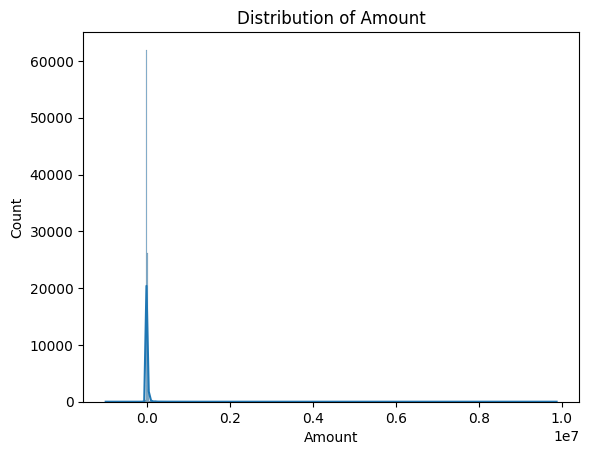

In [18]:
sns.histplot(df["Amount"], kde=True)
plt.title("Distribution of Amount")
plt.show()

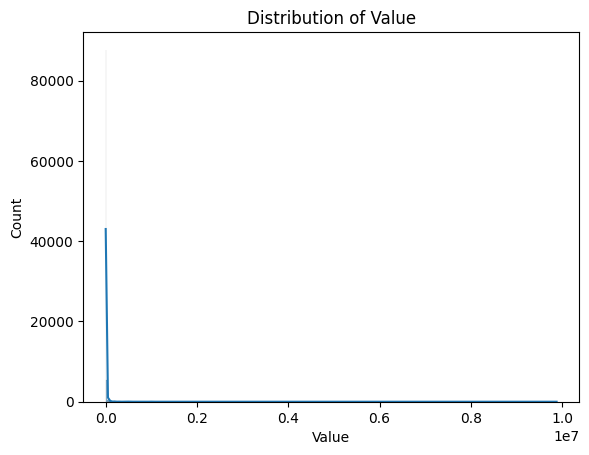

In [19]:
sns.histplot(df["Value"], kde=True)
plt.title("Distribution of Value")
plt.show()


Categorical Distributions

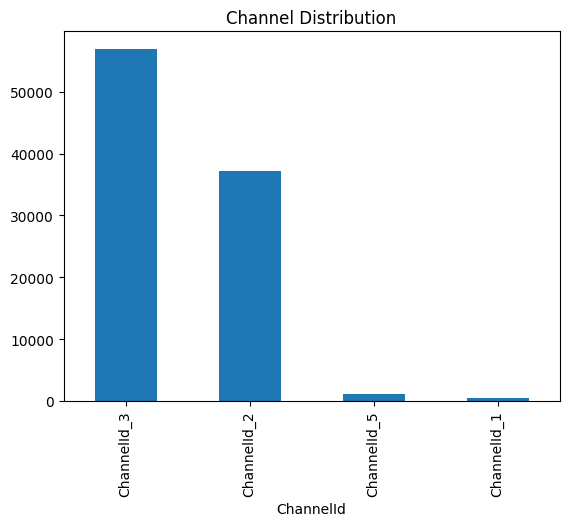

In [20]:
df["ChannelId"].value_counts().plot(kind="bar")
plt.title("Channel Distribution")
plt.show()

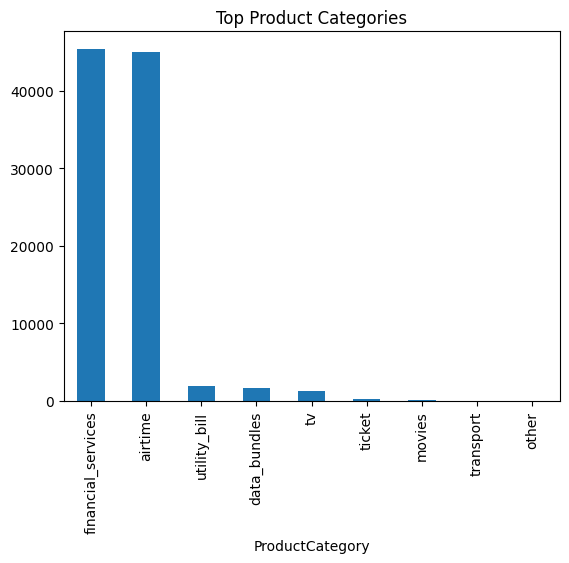

In [21]:
df["ProductCategory"].value_counts().head(10).plot(kind="bar")
plt.title("Top Product Categories")
plt.show()

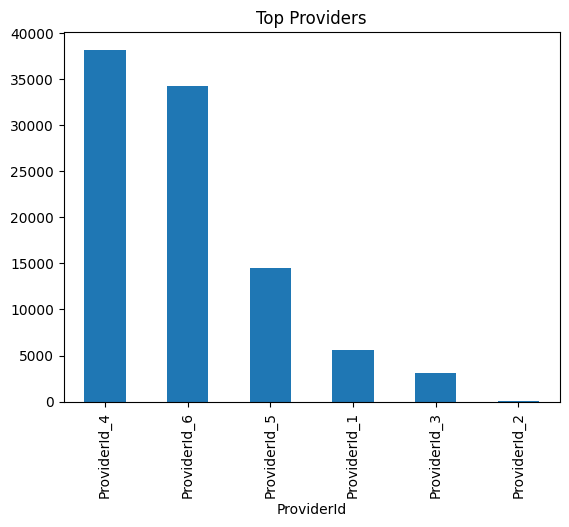

In [22]:
df["ProviderId"].value_counts().head(10).plot(kind="bar")
plt.title("Top Providers")
plt.show()

correlation analysis


In [23]:
numeric = df.select_dtypes(include=np.number)

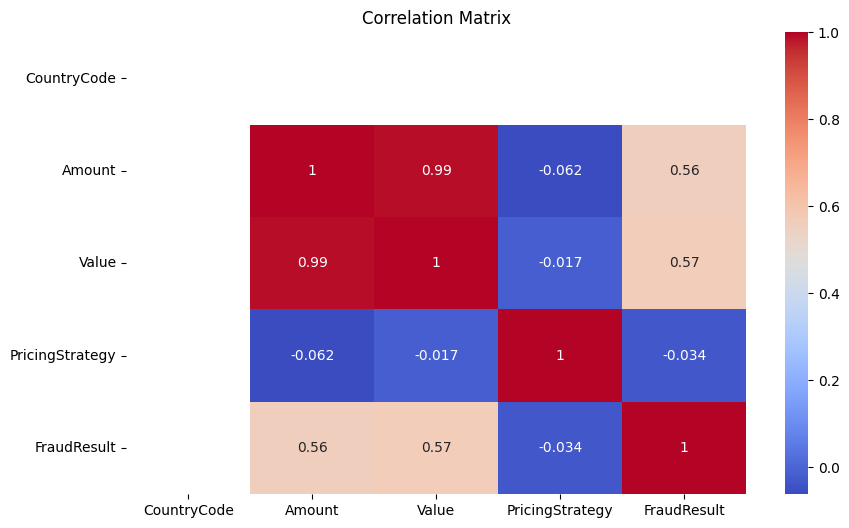

In [24]:
plt.figure(figsize=(10,6))
sns.heatmap(numeric.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()


time feature analysis 


In [25]:
df["TransactionStartTime"] = pd.to_datetime(df["TransactionStartTime"])

In [26]:
df["hour"] = df["TransactionStartTime"].dt.hour

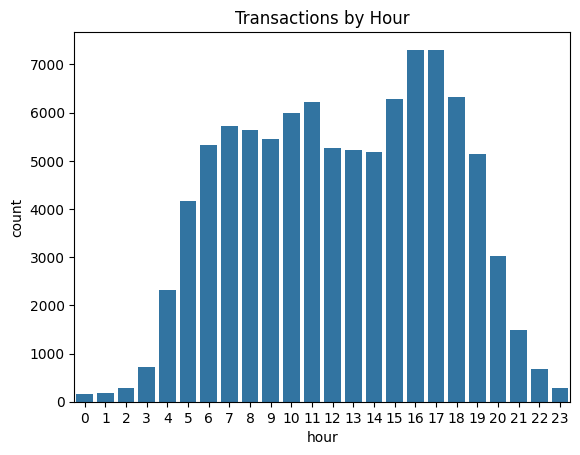

In [27]:
sns.countplot(x="hour", data=df)
plt.title("Transactions by Hour")
plt.show()

In [28]:
df["month"] = df["TransactionStartTime"].dt.month

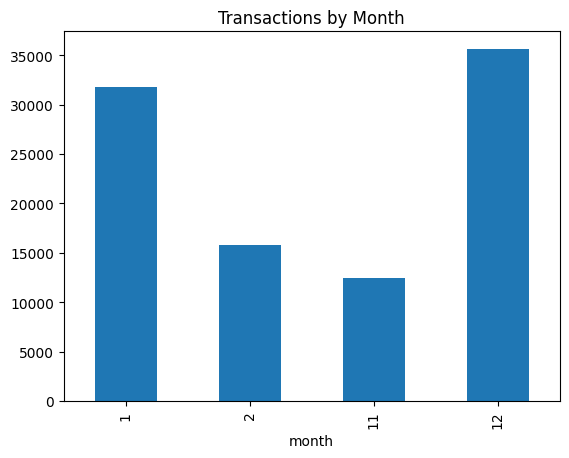

In [ ]:
df["month"].value_counts().sort_index().plot(kind="bar")
plt.title("Transactions by Month")
plt.show()

Outlier Detection

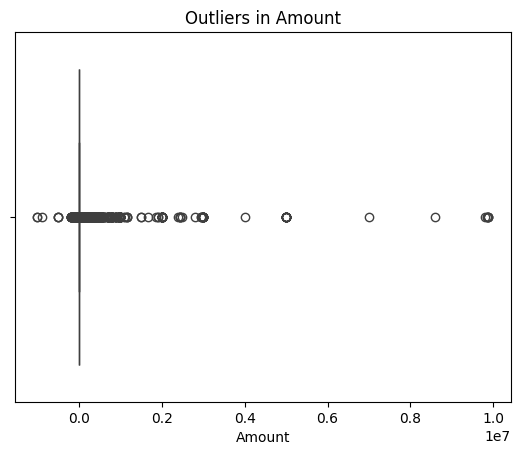

In [ ]:
sns.boxplot(x=df["Amount"])
plt.title("Outliers in Amount")
plt.show()

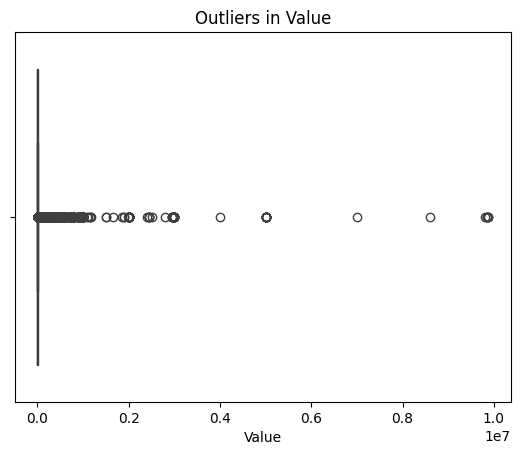

In [31]:
sns.boxplot(x=df["Value"])
plt.title("Outliers in Value")
plt.show()

In [32]:
df["FraudResult"].value_counts()

FraudResult
0    95469
1      193
Name: count, dtype: int64

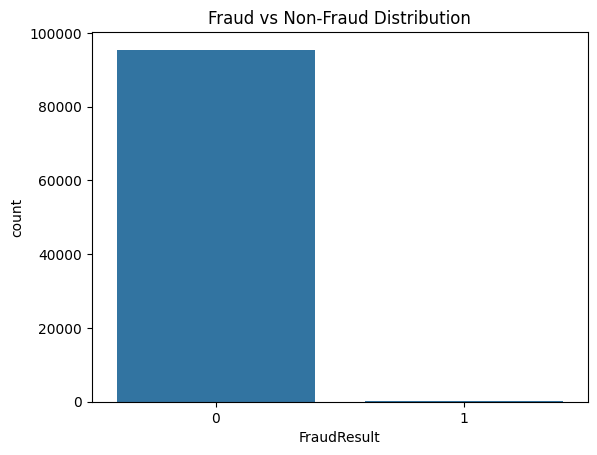

In [33]:
sns.countplot(x="FraudResult", data=df)
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()

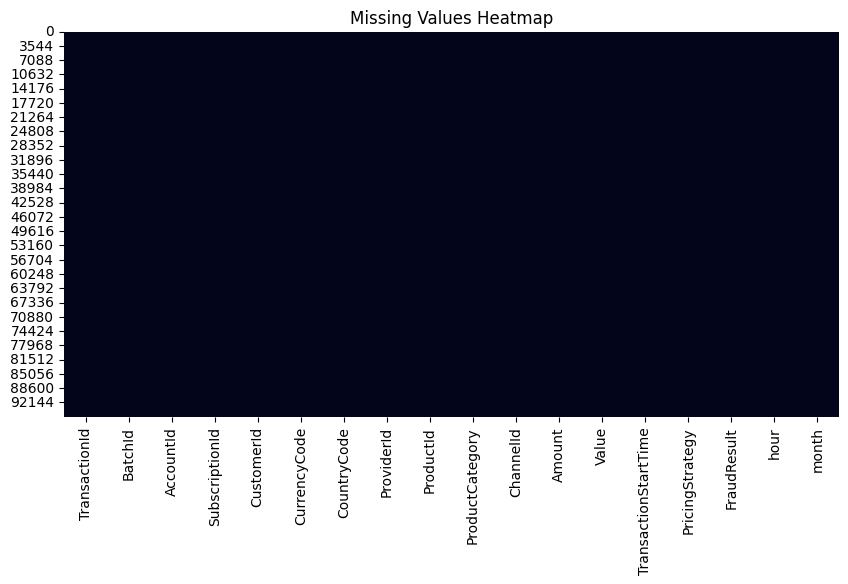

In [34]:
plt.figure(figsize=(10,5))
sns.heatmap(df.isnull(), cbar=False)
plt.title("Missing Values Heatmap")
plt.show()

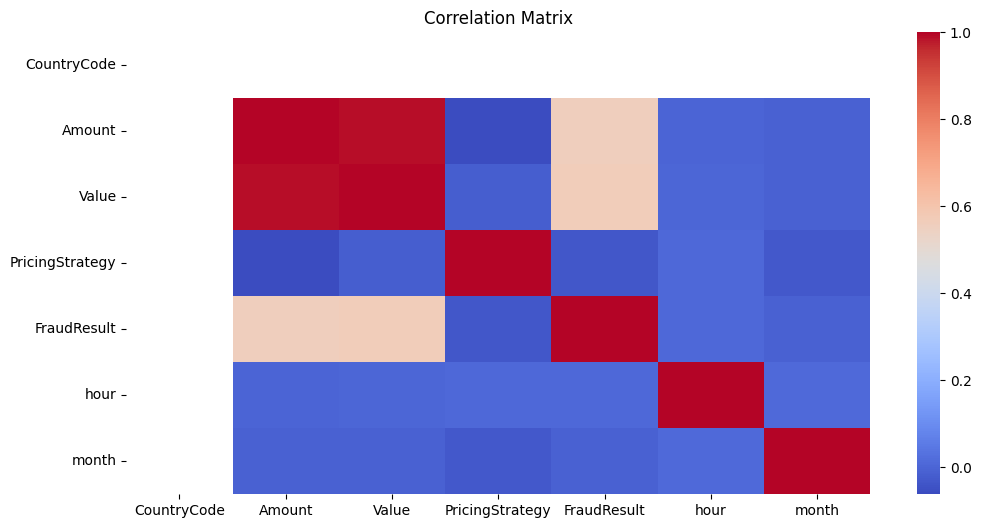

In [35]:
plt.figure(figsize=(12,6))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

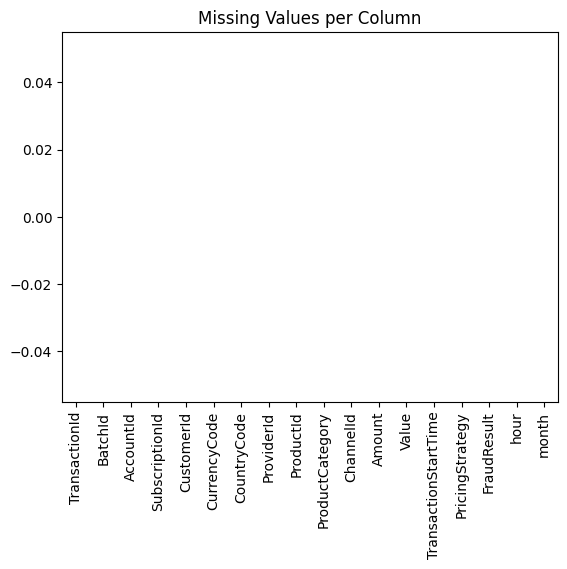

In [36]:
df.isnull().sum().plot(kind="bar")
plt.title("Missing Values per Column")
plt.show()

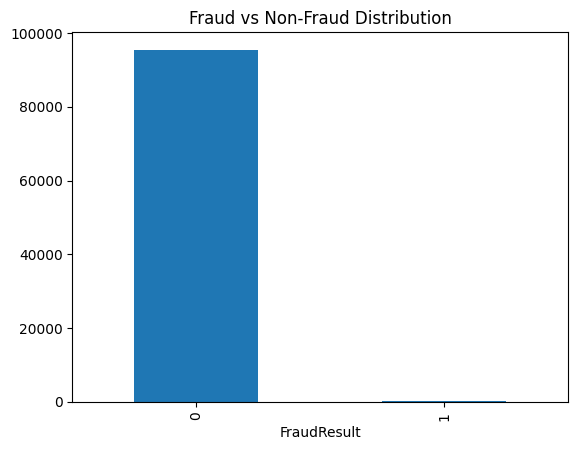

In [37]:
df["FraudResult"].value_counts().plot(kind="bar")
plt.title("Fraud vs Non-Fraud Distribution")
plt.show()

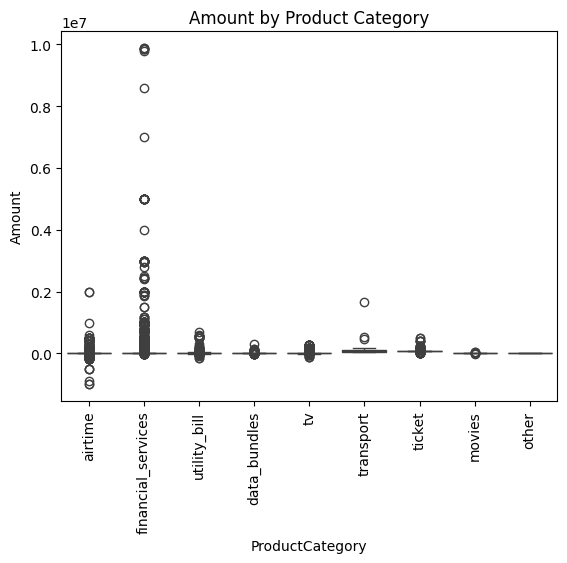

In [38]:
sns.boxplot(x="ProductCategory", y="Amount", data=df)
plt.xticks(rotation=90)
plt.title("Amount by Product Category")
plt.show()

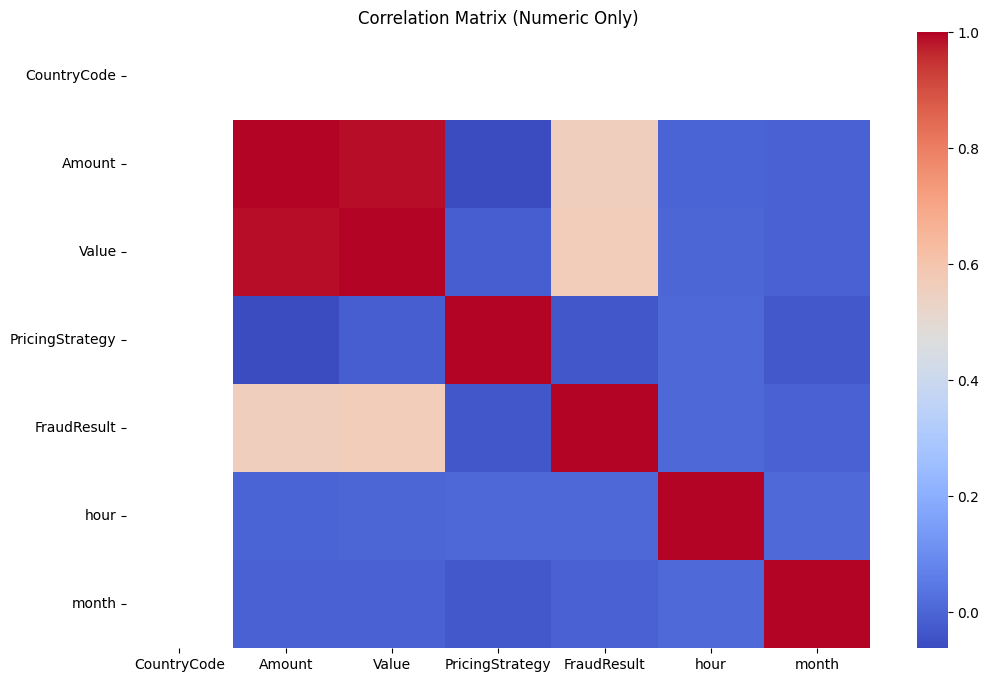

In [39]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm")
plt.title("Correlation Matrix (Numeric Only)")
plt.show()

📌 Top Insights
1,Transaction values are highly skewed, with a small number of extreme high-value transactions indicating potential outliers or fraud-prone behavior.

2,Certain providers (ProviderId) dominate transaction volume, suggesting strong dependency on a few service providers.

3,Transactions are more frequent during specific hours, indicating clear time-based behavioral patterns.

4,Product categories show uneven distribution, with a few categories dominating customer usage.

5,Strong correlation exists between Amount and Value, meaning they may carry redundant information for modeling.